# RadHarmony: Evaluating a Foundation Model

This notebook evaluates foundation models on radiology datasets. It assumes you
are already comfortable loading a dataset in RadHarmony.

The backbone of the notebook is **MedGemma**, used three ways:

1. Its **image encoder** for a linear probe (TB classification on Montgomery).
2. The full model for **visual question answering** (VQA-RAD).
3. The full model for **chest-X-ray report generation** (MIMIC-CXR).

The VQA and report-gen sections follow the MedGemma paper's protocol (same model,
prompts, decoding, metrics), so results are comparable to the paper. Each section
ends with a **"try it yourself"** cell that swaps in a different model or dataset,
leaving a few arguments for you to fill in.

## Setup

All three sections use MedGemma-family models on a recent `transformers`, so one
environment covers everything:

```bash
uv pip install -e ".[medsiglip,medgemma_gen]"
```

Requirements:

- **A GPU** (weights download on first use).
- **Hugging Face auth**. `google/medsiglip-448` and `google/medgemma-4b-it` are
  gated. Accept their licenses, then run `.venv/bin/hf auth login` once.

The RadGraph metric in the last section may need its own `radeval` environment
(see that section's note).

In [1]:
import os

# Pick the GPU. Must run BEFORE torch/CUDA is imported below, so `device_map="auto"`
# in the two VLM sections sees only this device instead of every GPU on the machine.
os.environ["CUDA_VISIBLE_DEVICES"] = "5"
DEVICE = "cuda"  # after the mask, the chosen GPU is cuda:0

from radharmony.dataset import MontgomeryCXRDataset

MONTGOMERY_DIR = "/mnt/NAS4/datasets/external/Montgomery-CXR/MontgomerySet/CXR_png"

## Foundation models and linear probes

A **foundation model** is pre-trained on lots of data; its learned representations
transfer to new tasks without retraining. The cheapest way to test one is a
**linear probe**: freeze the model, turn each image into an embedding, then fit a
small classifier on top.

MedGemma is a vision-language model, so its native output is text. But its image
encoder, [MedSigLIP](https://huggingface.co/google/medsiglip-448) (shipped
separately by Google), produces embeddings. Below we probe MedSigLIP on
tuberculosis classification (Montgomery set). Each encoder expects its own
normalization, so we pass the recipe's `transform` to the dataset;
`LinearProbeEvaluator` then embeds every image, runs 5-fold cross-validation, and
scores each held-out fold.

In [2]:
from radharmony.evaluator.backbones import make_medsiglip
from radharmony.evaluator import LinearProbeEvaluator

# MedSigLIP is MedGemma-4B's image encoder (google/medsiglip-448, gated on HF).
# The recipe returns (transform, image encoder, text encoder, processor); a
# linear probe needs only the first two.
transform, encoder, _text_encoder, _processor = make_medsiglip(
    device=DEVICE, output_keys={"img", "cls"}
)

Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

In [3]:
probe_ds = MontgomeryCXRDataset(
    base_image_dir=MONTGOMERY_DIR,
    transform=transform,  # MedSigLIP's preprocessing, not RadHarmony's default
    output_cls=True,
    cache_dir=None,
)

# LinearProbeEvaluator does the rest: embed every image, run 5-fold CV, score folds.
probe = LinearProbeEvaluator(
    image_encoder=encoder,
    dataset=probe_ds,
    n_folds=5,
    batch_size=32,
    device=DEVICE,
    embedding_cache="./cache/montgomery_medsiglip_emb",  # embeddings reused on re-runs
)
results = probe.evaluate()

# Average metrics across the folds, per label.
results.groupby("label")[["auroc", "auprc", "f1"]].mean()

,auroc,auprc,f1
label,,,
macro_average,0.972443,0.975077,0.947694
tb,0.972443,0.975077,0.947694


A per-label metrics table (AUROC, AUPRC, F1, and more). This is the shape **every**
RadHarmony evaluator returns, so scores across models are directly comparable.
AUROC measures how well the model separates positives from negatives (1.0 perfect,
0.5 chance). k-NN, SVM, prototype, zero-shot, fine-tune, and segmentation all share
this same interface.

### Seeing the predictions

The same probe also assigns a probability to each image. Reusing the cached
embeddings, we train the TB head on one fold's patients and read off `P(TB)` for a
few held-out validation images, pairing each with its true label.

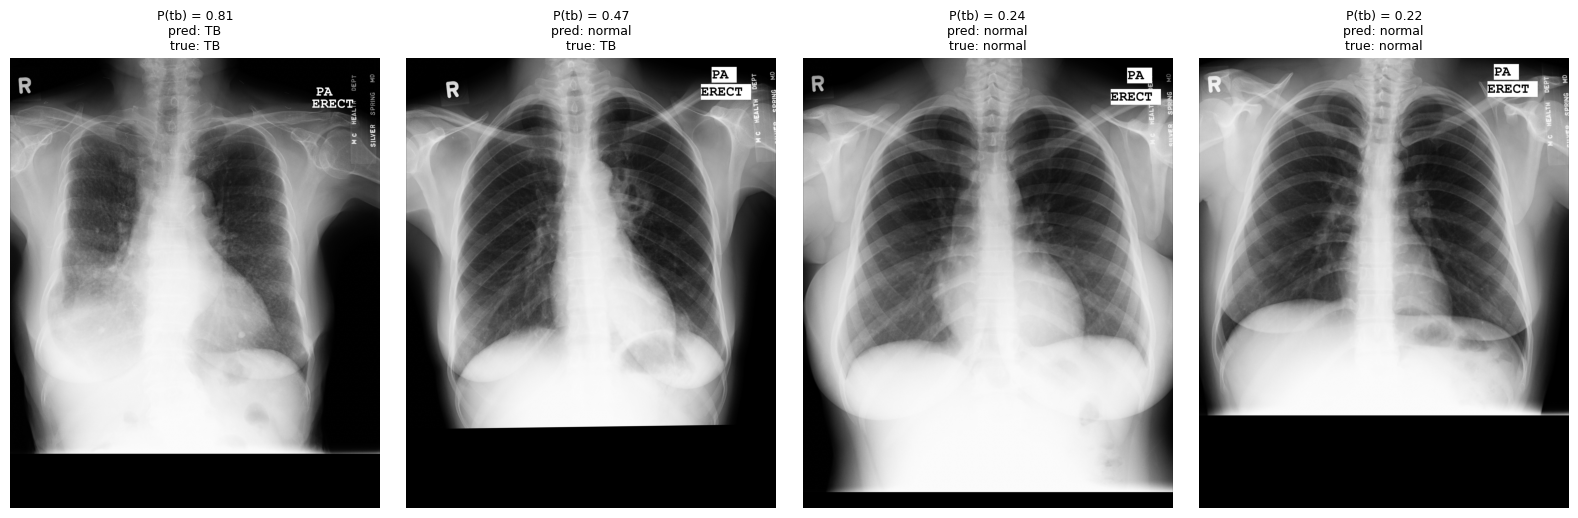

In [4]:
from viz_helpers import show_predictions

show_predictions(probe, probe_ds, MONTGOMERY_DIR)

### Try it yourself: a different encoder, a different dataset

The probe above ran **MedSigLIP** on **Montgomery** (one label: TB). The evaluator
doesn't care which encoder or dataset it gets, so swap both and the call is identical.
Below: **RAD-DINO** (`make_raddino`, a CXR-specialized DINOv2) probed on **VinDr-CXR**,
a 28-finding *multi-label* benchmark, giving one AUROC row per finding plus a
`macro_average`.

> **The "try it yourself" cells leave some arguments as `...`.** Look each one up in
> the linked docs and fill it in. This applies to all five exercises below.

Vision-only recipes (`make_raddino`, `make_dinov3`) return `(transform, encoder)`;
CLIP-family recipes (`make_medsiglip`, `make_biomed_clip`) return a 4-tuple, so
unpack the extra two with `*_`.

In [ ]:
from radharmony.evaluator.backbones import make_raddino
from radharmony.dataset import VinDrCXRTestDataset

# TODO: swap make_raddino for another recipe. Vision-only recipes
# (make_raddino, make_dinov3, make_eva_x) return (transform, encoder);
# for a 4-tuple recipe use:  transform, encoder, *_ = make_medsiglip(...)
#
# FILL IN output_keys: which keys does a *classification* probe need?
#   docs: https://f10409.github.io/RadHarmony/backbones/raddino.html
transform, encoder = make_raddino(device=DEVICE, output_keys=...)

# VinDr-CXR test split (DICOM): 28 findings, multi-label.
VINDR_DIR = (
    "/mnt/NAS4/datasets/external/VinDr-CXR/physionet.org/files/vindr-cxr/1.0.0/test/"
)
vindr_ds = VinDrCXRTestDataset(
    base_image_dir=VINDR_DIR,
    transform=transform,  # the encoder's own preprocessing
    output_cls=...,  # FILL IN: what does a probe read? docs: https://f10409.github.io/RadHarmony/datasets/vindr_cxr.html
    cache_dir=None,
)

probe = LinearProbeEvaluator(
    image_encoder=encoder,
    dataset=vindr_ds,
    n_folds=5,
    batch_size=32,
    device=DEVICE,
    embedding_cache="./cache/vindr_raddino_emb",
)
results = probe.evaluate()

# 28 findings -> 28 label rows + a macro_average; show the ten best-separated.
(
    results.groupby("label")[["auroc", "auprc", "f1"]]
    .mean()
    .sort_values("auroc", ascending=False)
    .head(10)
)

### Try it yourself: zero-shot, no probe training

A linear probe still fits a small classifier. A **vision-language** model can skip
even that: embed the image, embed a text prompt per class, and score by cosine
similarity. No training, no folds, so the *prompt wording* is the only knob.
`make_biomed_clip` hands back a text encoder and tokenizer alongside the image
encoder, and `ZeroShotEvaluator` turns per-label prompts into class prototypes.
Here **BiomedCLIP** scores **RSNA Pneumonia** images for `lung_opacity` vs `normal`;
reword the prompts and watch AUROC move.

In [ ]:
from radharmony.evaluator import ZeroShotEvaluator
from radharmony.evaluator.backbones import make_biomed_clip
from radharmony.dataset import RSNAPneumoniaKaggleTrainDataset

# make_biomed_clip returns FOUR objects. Which is the text encoder? the tokenizer?
#   docs: https://f10409.github.io/RadHarmony/backbones/biomed_clip.html
transform, encoder, text_encoder, tokenizer = make_biomed_clip(device=DEVICE)

RSNA_DIR = "/mnt/NAS4/datasets/external/rsna-pneumonia-detection-challenge/stage_2_train_images/"
RSNA_CSV = "/mnt/NAS4/datasets/external/rsna-pneumonia-detection-challenge/stage_2_train_labels.csv"
zs_ds = RSNAPneumoniaKaggleTrainDataset(
    base_image_dir=RSNA_DIR,
    csv_path=RSNA_CSV,
    transform=transform,
    output_cls=True,
    cache_dir=None,
)

ev = ZeroShotEvaluator(
    image_encoder=encoder,
    text_encoder=...,  # FILL IN: which object from make_biomed_clip? docs: https://f10409.github.io/RadHarmony/evaluator/zero_shot.html
    tokenizer=...,  # FILL IN: ditto
    dataset=zs_ds,
    labels=...,  # FILL IN: two of RSNA's 3 classes; LABEL_COLS at https://f10409.github.io/RadHarmony/datasets/rsna_pneumonia_kaggle.html
    # The prompts ARE the experiment, so reword them freely.
    prompts={
        "lung_opacity": [
            "a chest x-ray showing lung opacity",
            "chest x-ray with pneumonia",
        ],
        "normal": ["a normal chest x-ray", "clear lungs, no acute abnormality"],
    },
    negative_prompts={
        "lung_opacity": ["a normal chest x-ray with clear lungs"],
    },
    embedding_cache="./cache/rsna_biomedclip_emb",
)
ev.evaluate()

### Segmentation probe

The same frozen encoder can be probed for **segmentation** instead of
classification. In segmentation mode (`output_keys={"img", "mask"}`) the encoder
returns dense `[B, D, H, W]` feature maps rather than one vector per image, and
`LinearProbeSegEvaluator` trains a small 1x1 conv head on top to predict a mask.

We segment the **lungs** on Montgomery, which ships left+right lung masks.
Everything else (frozen backbone, 5-fold CV, per-class metrics) mirrors the
classification probe above.

In [5]:
from radharmony.evaluator import LinearProbeSegEvaluator

# Same MedSigLIP, now in segmentation mode: output_keys={"img", "mask"} makes the
# encoder emit dense [B, D, H, W] feature maps instead of one [B, D] vector.
seg_transform, seg_encoder, _text_encoder, _processor = make_medsiglip(
    device=DEVICE, output_keys={"img", "mask"}
)

# Montgomery ships left+right lung masks; output_mask=True fuses them into one
# binary lung mask per image, written to mask_output_dir.
seg_ds = MontgomeryCXRDataset(
    base_image_dir=MONTGOMERY_DIR,
    transform=seg_transform,
    output_mask=True,
    mask_output_dir="./cache/montgomery_lung_masks",
    cache_dir=None,
)

# Trains a 1x1 conv head over the frozen features per fold (background + lung).
seg_probe = LinearProbeSegEvaluator(
    image_encoder=seg_encoder,
    dataset=seg_ds,
    num_classes=2,
    n_folds=5,
    epochs=20,
    batch_size=8,
    device=DEVICE,
)
seg_results = seg_probe.evaluate()

# Average Dice / IoU across folds, per class.
seg_results.groupby("label")[["dice", "iou"]].mean()

Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

Fusing lung masks: 100%|██████████| 138/138 [00:00<00:00, 57206.36it/s]


training:   0%|          | 0/20 [00:00<?, ?epoch/s]

training:   0%|          | 0/20 [00:00<?, ?epoch/s]

KeyboardInterrupt: 

A per-class table of segmentation metrics (Dice, IoU, pixel accuracy, sensitivity,
specificity). `class_1` is the lung; `macro_average` aggregates the foreground
classes. Dice measures overlap between predicted and true mask (1.0 perfect, 0.0
disjoint). `ConvProbeSegEvaluator` (deeper head) and `UPerNetSegEvaluator` (full
decoder) drop in through the same interface.

### Seeing the predicted masks

`fit()` trains one deployment head (no k-fold) and `predict(..., return_images=True)`
runs it over the inner-val slice `fit()` held out, returning the resized image,
ground-truth mask, and predicted mask per example, ready for overlays.

In [ ]:
from viz_helpers import show_masks

show_masks(seg_probe, seg_ds)

### Try it yourself: segment a different finding with a different encoder

Point the same `LinearProbeSegEvaluator` at **SIIM-ACR Pneumothorax** with a
**RAD-DINO** backbone to segment the pneumothorax region instead. SIIM ships
run-length-encoded masks; `output_mask=True` + `mask_output_dir` decodes them to
PNGs once (cached after). Everything else stays the same as the lung probe: frozen
backbone in `output_keys={"img", "mask"}` mode, 5-fold CV, Dice / IoU per class.

In [ ]:
from radharmony.evaluator.backbones import make_raddino
from radharmony.dataset import SIIMACRPTXTrainDataset

# FILL IN output_keys for *segmentation* mode (dense [B, D, H, W] maps, not one vector).
#   docs: https://f10409.github.io/RadHarmony/backbones/raddino.html
seg_transform, seg_encoder = make_raddino(device=DEVICE, output_keys=...)

SIIM_DIR = "/mnt/NAS3/datasets/external/SIIM_ACR_Pneumothorax/dicom-images-train/"
SIIM_CSV = "/mnt/NAS3/datasets/external/SIIM_ACR_Pneumothorax/train-rle.csv"
# RLE masks in the CSV are decoded to PNGs under mask_output_dir on first load.
siim_ds = SIIMACRPTXTrainDataset(
    base_image_dir=SIIM_DIR,
    csv_path=SIIM_CSV,
    transform=seg_transform,
    output_mask=True,
    mask_output_dir="./cache/siim_ptx_masks",
    cache_dir=None,
)

seg_probe = LinearProbeSegEvaluator(
    image_encoder=seg_encoder,
    dataset=siim_ds,
    num_classes=...,  # FILL IN: background + pneumothorax = ? docs: https://f10409.github.io/RadHarmony/evaluator/linear_probe_seg.html
    n_folds=5,
    epochs=20,
    batch_size=8,
    device=DEVICE,
)
seg_probe.evaluate().groupby("label")[["dice", "iou"]].mean()

## Visual question answering (MedGemma protocol)

The probe used only the image encoder; the full **vision-language model** can
answer questions about an image. `VQAEvaluator` runs this, and
`make_medgemma_vqa` reproduces the MedGemma paper's setup (§3.4, Table 9):

- **Model**: MedGemma-4B instruction-tuned (`google/medgemma-4b-it`).
- **Prompt**: the exact VQA-RAD prompt from Appendix A7.
- **Decoding**: greedy (temperature 0).
- **No system persona**: the paper omits it for medical variants, and we match
  (`system_message=None`).
- **Metrics**: token F1 over all questions plus accuracy on the yes/no ("closed")
  subset.

The paper uses VQA-RAD and SLAKE; we use VQA-RAD (swap the dataset for SLAKE).

In [6]:
from radharmony.evaluator import VQAEvaluator
from radharmony.evaluator.backbones import make_medgemma_vqa
from radharmony.dataset import VQARadDataset

VQA_RAD_DIR = "/mnt/NAS4/datasets/external/VQA-RAD/VQA_RAD Image Folder"

# make_medgemma_vqa loads google/medgemma-4b-it and returns a transform (each
# image -> a PNG path the model reads) and an answerer (greedy decoding). It uses
# device_map="auto", so GPU pinning comes from the setup cell's
# CUDA_VISIBLE_DEVICES, not the `device` arg.
transform, answerer = make_medgemma_vqa(device=DEVICE)

vqa_ds = VQARadDataset(base_image_dir=VQA_RAD_DIR, transform=transform, cache_dir=None)

ev = VQAEvaluator(answerer, dataset=vqa_ds, output_dir="outputs/vqa")
df = ev.evaluate()
ev.save_results(df)  # writes results.csv + generations.csv to output_dir
df

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

answering VQA:   0%|          | 0/281 [00:00<?, ?batch/s]

Mean of empty slice
Degrees of freedom <= 0 for slice.


,fold,seed,bootstrap,label,token_f1,accuracy,token_recall
0,-1,-1,-1,overall,0.565488,NaN,NaN
1,-1,-1,-1,closed,0.753562,0.753562,NaN
2,-1,-1,-1,open,0.352811,NaN,0.34318


One row per bucket, matching MedGemma's Table 9; each reports only the metrics that
make sense for it (hence the NaNs). Answers are normalized (lowercased, punctuation
and articles stripped, tokenized) then scored on token overlap. The examples below
use real VQA-RAD questions with illustrative predictions.

**`overall`: mean token F1 across every question.** Token F1 is the multiset
overlap: `P = overlap/|pred|`, `R = overlap/|ref|`, `F1 = 2PR/(P+R)`.

> Q: *"where is the cavitary lesion?"* · ref `"Right upper lobe"` →
> `[right, upper, lobe]` · pred `"left upper lobe"` → `[left, upper, lobe]`.
> Overlap = 2, so P = R = 2/3, **F1 ≈ 0.67** (right structure, wrong side).

**`closed`: accuracy on yes/no questions** plus their token F1. Accuracy grades the
first yes/no token the model emits, so a full sentence still counts.

> Q: *"Are the lungs normal appearing?"* · ref `"No"` · pred
> `"No, there are pulmonary nodules."` → first yes/no token is `no` → **correct
> (1.0)**. A pred of `"yes"` would score **0.0**.

**`open`: token F1 and token recall on the rest.** Recall is `overlap/|ref|`, the
fraction of reference tokens recovered; the two together separate completeness from
concision.

> Q: *"What abnormalities are seen within the lungs?"* · ref `"Pulmonary nodules"`
> · pred `"there are multiple pulmonary nodules"`. Overlap = 2 → **recall = 1.0**
> but **F1 ≈ 0.57** (P = 2/5, docked for the extra words).

Swap `make_chexagent_vqa` for CheXagent-2. These numbers cover the full VQA-RAD set;
the paper's contamination-free split isn't shipped, so values aren't bit-comparable.

### Seeing the answers

`ev.save_results(df)` writes `generations.csv` with every answer; here we pair a few
images with what the model said, running the same `answerer` on samples pulled
straight from the dataset (each sample's `img` is the PNG path the transform wrote).

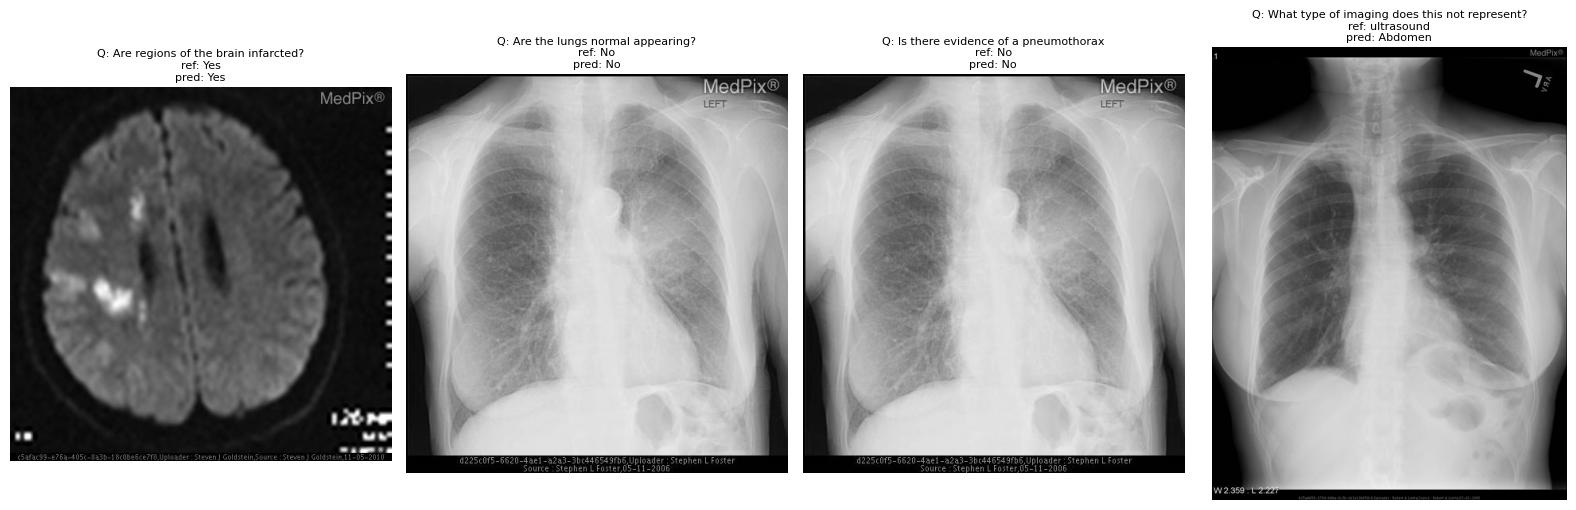

In [7]:
from viz_helpers import show_answers

show_answers(vqa_ds, answerer)

### Try it yourself: a different VQA model

Swap the recipe for **CheXagent-2** (`make_chexagent_vqa`), a CXR-specialist VLM.
The harness, dataset, prompt handling, and metrics stay put; only the two lines that
build the model change.

> **Needs its own environment.** CheXagent-2 pins `transformers==4.40.0`, which
> conflicts with the MedGemma stack this notebook set up (`transformers>=5.6.0`).
> Install the `chexagent_gen` extra in a separate venv and run this cell from there:
>
> ```bash
> uv pip install -e ".[chexagent_gen]"
> ```


In [ ]:
from radharmony.evaluator.backbones import make_chexagent_vqa

# CheXagent-2 instead of MedGemma; returns (transform, answerer) like the MedGemma recipe.
transform, answerer = make_chexagent_vqa(device=DEVICE)

vqa_ds = VQARadDataset(base_image_dir=VQA_RAD_DIR, transform=transform, cache_dir=None)

# FILL IN VQAEvaluator's first (positional) argument.
#   docs: https://f10409.github.io/RadHarmony/evaluator/vqa.html
ev = VQAEvaluator(..., dataset=vqa_ds, output_dir="outputs/vqa_chexagent")
ev.evaluate()

## Generating chest-X-ray reports (MedGemma protocol)

VQA asks a question; **report generation** asks the model to *write* the
findings. Same MedGemma-4B, different prompt. `make_medgemma_generator`
reproduces the paper's setup:

- **Task**: write the FINDINGS section for a MIMIC-CXR chest X-ray.
- **Indication-conditioned**: the exam's clinical indication is passed as
  context (fair: the reporting radiologist reads it too; it's input, not a
  scoring target).
- **Decoding**: greedy.
- **Metrics**: **RadGraph F1** (MedGemma's headline metric) plus **BLEU** for
  an n-gram-overlap point of comparison, both via RadEval. The demo scores
  findings; use `ref_section="impression"` for impression.

No training phase: the evaluator iterates the dataset once, generates, scores.

> **Environment.** RadGraph pins a different `transformers` from MedGemma. For a
> large run, generate here with `ev.generate_only("pairs.parquet")`, then score
> the parquet in a `radeval` venv (`uv pip install -e ".[radeval]"`). This demo
> scores inline. MIMIC-CXR is credentialed (PhysioNet).

> **First-run auth.** RadGraph downloads weights from `StanfordAIMI/RRG_scorers`
> on the first `ev.evaluate()`. If it 401s: (1) no HF token, run
> `.venv/bin/hf auth login` with a `read`-scoped token; (2) a pre-Xet token on
> the Xet-hosted repo, so regenerate it, or set `HF_HUB_DISABLE_XET=1` before
> launching Jupyter. Cached after the first successful download.

In [2]:
from radharmony.evaluator import ReportGenerationEvaluator
from radharmony.evaluator.backbones import make_medgemma_generator
from radharmony.dataset import MIMICCXRDataset

# MIMIC-CXR is credentialed (PhysioNet). Point these at your local copy.
MIMIC_IMAGE_DIR = "/mnt/NAS4/datasets/external/MIMIC-CXR-V2-AWS/files/"
MIMIC_REPORT_CSV = "/mnt/NAS4/datasets/external/MIMIC-CXR-V2-AWS/cxr-study-list.csv.gz"

# Same MedGemma-4B, now writing a findings narrative. Returns a transform (image
# -> PNG path) and a generator (greedy). Default prompt is the "<INDICATION>
# findings:" form; override with make_medgemma_generator(prompt="..."). Same
# device_map="auto" caveat as the VQA cell.
transform, generator = make_medgemma_generator(device=DEVICE)

# output_report=True makes each sample carry its reference report path.
gen_ds = MIMICCXRDataset(
    base_image_dir=MIMIC_IMAGE_DIR,
    report_csv_path=MIMIC_REPORT_CSV,
    transform=transform,
    output_report=True,
    cache_dir=None,
)

ev = ReportGenerationEvaluator(
    generator,
    dataset=gen_ds,
    ref_section="findings",  # swap to "impression" for that column
    use_indication=True,  # condition on the exam indication (input, not a target)
    metrics=[
        "bleu",
        "radgraph",
    ],  # BLEU (n-gram overlap) + RadGraph F1 (MedGemma's primary)
    max_samples=1000,  # small cap for the demo; remove for a full run
    output_dir="outputs/medgemma_report",
)
df = ev.evaluate()
ev.save_results(df)  # writes results.csv + generations.csv to output_dir
df

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generating reports:   0%|          | 0/47139 [00:00<?, ?batch/s]

KeyboardInterrupt: 

One row (`label == "report"`): a `bleu` column plus three RadGraph columns,
`radgraph_simple`, `radgraph_partial`, `radgraph_complete` (explained below). The two
metrics measure different things:

- **BLEU**: n-gram overlap with a brevity penalty. Surface-level and
  phrasing-sensitive: a clinically correct report worded differently scores low.
- **RadGraph F1**: extracts the clinical entities and relations from both reports
  and scores how well they match. Rewards the right *findings*, not the phrasing.

Reporting both shows the gap between lexical and clinical agreement. This is a close
replication, not a bit-exact reproduction: the demo scores findings
(`ref_section="impression"` for the other), MedGemma's exact prompt isn't published
(the recipe uses a faithful paraphrase, override with `prompt=`), and it runs over
whatever MIMIC-CXR split you pass.

### Seeing the generated reports

`ev.save_results(df)` writes `generations.csv` with reference and generated findings
side by side; here we show a few images beside both, running the same `generator` on
samples from the dataset (each `report` is the path to the reference report).

In [ ]:
from viz_helpers import show_reports

show_reports(gen_ds, generator)

### Try it yourself: a different report generator

`make_chexagent_generator` (CheXagent-2) and `make_maira2_generator` (MAIRA-2) both
return `(transform, generator)` and drop straight into `ReportGenerationEvaluator`.
Swap the recipe; keep the MIMIC-CXR dataset, `findings` scoring, and the
RadGraph + BLEU metrics.

In [ ]:
from radharmony.evaluator.backbones import make_chexagent_generator

# from radharmony.evaluator.backbones import make_maira2_generator  # MAIRA-2 instead
transform, generator = make_chexagent_generator(device=DEVICE)

gen_ds = MIMICCXRDataset(
    base_image_dir=MIMIC_IMAGE_DIR,
    report_csv_path=MIMIC_REPORT_CSV,
    transform=transform,
    output_report=True,
    cache_dir=None,
)

# FILL IN ref_section and metrics.
#   docs: https://f10409.github.io/RadHarmony/evaluator/report_generation.html
ev = ReportGenerationEvaluator(
    generator,
    dataset=gen_ds,
    ref_section=...,  # which report section to score?
    metrics=...,  # n-gram overlap + RadGraph F1
    max_samples=1000,  # small cap for the demo; remove for a full run
    output_dir="outputs/chexagent_report",
)
ev.evaluate()

### How the RadGraph F1 columns are computed

RadEval returns three RadGraph F1 columns (`radgraph_simple`,
`radgraph_partial`, `radgraph_complete`): same metric, three severity levels.

**What RadGraph extracts.** A trained extractor (DyGIE++ with RadGraph-XL
weights) reads each report and returns a small graph:

- **Entities**: token spans labelled `ANAT-DP` (anatomy present), `OBS-DP`
  (observation present), `OBS-U` (uncertain), `OBS-DA` (absent).
- **Relations**: typed directed edges (`located_at`, `modify`,
  `suggestive_of`), always *source → target* (`small --modify--> pneumothorax`).

The same extractor runs on both reports, so its errors partially cancel.

**Reference.** *"Small pneumothorax in the right lung apex"* → `pneumothorax`
(OBS-DP) `located_at` `apex`; `small` (OBS-DP) `modify` `pneumothorax`; `right`
(ANAT-DP) `modify` `apex`; `apex` (ANAT-DP), no outgoing edge. (See the diagram
below.)

**Scoring.** Each report becomes a set of tuples, then `P = matched / |hyp|`,
`R = matched / |ref|`, `F1 = 2PR/(P+R)`. The columns differ only in the tuple
shape each entity contributes:

| Column | Tuple form | Semantics |
|---|---|---|
| `radgraph_simple`   | `(tokens, label)` | Entity only; relations ignored. |
| `radgraph_partial`  | `(tokens, label)`, or `(tokens, label, True)` if it has an outgoing edge | Entity + whether it links to *something*. |
| `radgraph_complete` | `(tokens, label)`, or one `(tokens, label, rel, target)` **per outgoing edge** | The full edge. |

**Example 1: "...in the LEFT apex" (wrong side).** Only `right`→`left` changes.
At every level 3 of 4 tuples match and the single token error is charged exactly
once: **simple = partial = complete = 0.75**.

**Example 2: "Pneumothorax is present" (ungrounded).** The extractor returns
one entity, `pneumothorax` (OBS-DP), no relations.

- *simple*: `hyp = {(pneumothorax, OBS-DP)}`, 1 of 4 ref tuples matches →
  P = 1.00, R = 0.25, **F1 ≈ 0.40**.
- *partial / complete*: the reference's `pneumothorax` is a 3-/4-tuple (it has an
  outgoing edge), the hypothesis's is a bare 2-tuple → no match → **F1 = 0.00**.

| Hypothesis | simple | partial | complete |
|---|---:|---:|---:|
| "...in the **left** apex" | 0.75 | 0.75 | 0.75 |
| "Pneumothorax is present" | 0.40 | **0.00** | 0.00 |

Two takeaways:

- **`simple ≥ partial ≥ complete`** always holds, since a match on a stricter tuple
  implies a match on the looser one.
- **`partial` is where grounding gets scored.** Naming findings in isolation
  (Example 2) earns `simple` credit but zero `partial` credit, the behavior
  most RRG papers want punished.

**Which to quote against MedGemma.** MedGemma cites "RadGraph F1" without a
level; the convention is **`radgraph_partial`** (Yu et al. 2023's `F1RadGraph`
default). RadEval hardcodes `model_type="radgraph-xl"`; older BERT-based
`radgraph` numbers aren't directly comparable.

![RadGraph F1 worked examples: the reference graph and the two hypothesis graphs, side by side](figs/RadGraph.png)

*Reference vs. the two hypotheses from the examples above. Both `modify` arrows
point modifier → head; red marks what differs from the reference.*

## Build your own: any dataset, any model

Every section above is the **same four steps**. Once the pattern clicks you can point
RadHarmony at any of its 16 backbone recipes, ~60 datasets, and evaluator families:

1. **Model**: `make_<model>(device=DEVICE, output_keys=...)` returns a preprocessing
   `transform` plus an encoder/generator. Check the recipe's *Returns* for how many
   objects it hands back (2-tuple vs 4-tuple). See [backbone recipes](https://f10409.github.io/RadHarmony/backbones/index.html).
2. **Dataset**: `<Name>Dataset(base_image_dir=..., transform=transform, output_<task>=True)`.
   Always pass the recipe's `transform` so preprocessing matches the model.
   See [datasets](https://f10409.github.io/RadHarmony/datasets.html).
3. **Evaluator**: pick the one for your task (`LinearProbeEvaluator`, `ZeroShotEvaluator`,
   `LinearProbeSegEvaluator`, `VQAEvaluator`, `ReportGenerationEvaluator`, and more) and
   pass the encoder plus dataset. See [evaluators](https://f10409.github.io/RadHarmony/evaluator/index.html).
4. **Run**: `.evaluate()` returns a metrics DataFrame in the same shape every time.

Fill the blanks below to assemble your own run. Every placeholder (`make_YOUR_MODEL`,
`YourDataset`, `YourEvaluator`, and each `...`) is something the linked docs answer.

In [ ]:
# 1) MODEL: any recipe from radharmony.evaluator.backbones
from radharmony.evaluator.backbones import (
    make_YOUR_MODEL,
)  # e.g. make_dinov3, make_raddino, make_biomed_clip

# 2) DATASET: any class from radharmony.dataset
from radharmony.dataset import (
    YourDataset,
)  # e.g. CheXpertValidDataset, VinDrCXRTestDataset

# 3) EVALUATOR: the one matching your task
from radharmony.evaluator import (
    YourEvaluator,
)  # e.g. LinearProbeEvaluator, ZeroShotEvaluator

# How many objects does your recipe return? (see its docs page)
transform, encoder, *_ = make_YOUR_MODEL(device=DEVICE, output_keys=...)

ds = YourDataset(
    base_image_dir=...,  # the dataset's wiki page lists its NAS path
    transform=transform,  # always pass the recipe's transform
    output_cls=...,  # output_cls / output_mask / output_report: match your task
    cache_dir=None,
)

ev = YourEvaluator(
    image_encoder=encoder,
    dataset=ds,
    device=DEVICE,
    # + task-specific args (n_folds, num_classes, prompts, ref_section, metrics); see the evaluator page
)
ev.evaluate()

## Summary

Three ways to evaluate a foundation model in RadHarmony:

- **Linear probe**: `LinearProbeEvaluator` on frozen image embeddings.
- **VQA**: `VQAEvaluator` on generated answers (token F1 + closed accuracy).
- **Report generation**: `ReportGenerationEvaluator` on generated findings
  (RadGraph F1).

The VQA and report-gen sections follow the MedGemma paper's protocol. Swap in
another recipe (`make_chexagent_vqa`, `make_chexagent_generator`,
`make_maira2_generator`) to run a different model through the same harness.

Full docs: **[f10409.github.io/RadHarmony](https://f10409.github.io/RadHarmony)**